<a href="https://colab.research.google.com/github/Wesnei/Gera-o-de-Dados-Sint-ticos-via-VAE-e-Auditoria-L-gica-Neuro-Simb-lica/blob/main/DADOS_VAEs_XAI_FINAL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div align="center">
  <img src="https://github.com/sauloafoliveira/ppgcc-deep-learning/blob/main/ppgc_logo.png?raw=true" width="450">
  <br>
  <font size="4"><b>INSTITUTO FEDERAL DE EDUCAÇÃO, CIÊNCIA E TECNOLOGIA DO CEARÁ</b></font><br>
  <font size="3"><b>PROGRAMA DE PÓS-GRADUAÇÃO EM CIÊNCIA DA COMPUTAÇÃO - PPGCC</b></font><br>
  <font size="3">Mestrado Acadêmico em Ciência da Computação</font>
</div>

---
**Disciplina:** XAI com Raciocínio Automatizado – 2026.1  
**Docente:** Nivando Bezerra/Thiago Alves  
**Discentes:** Wesnei de Paiva Batista  
**Atividade:** Geração de Dados Sintéticos via Variational Autoencoders para Predição de Risco Cardiovascular: Uma Abordagem com Foco em Privacidade, Explicabilidade e Auditoria Neuro-Simbólica

---



## 1. Configuração do Ambiente e Preparação dos Dados

Nesta etapa inicial, realizamos a preparação do ambiente de desenvolvimento no Google Colab e a carga dos dados estruturados que servirão de base para o experimento neuro-simbólico.

* **Instalação de Dependências:** Instalação das bibliotecas `sdv` (para geração de dados sintéticos via TVAE), `shap` (para explicabilidade local e global) e `z3-solver` (para a auditoria lógica formal).
* **Carga do Dataset:** Importação do *UCI Cleveland Heart Disease Dataset*, um conjunto de dados consagrado na literatura para predição de risco cardiovascular.
* **Pré-processamento:** Tratamento de valores ausentes por imputação de mediana e binarização da variável alvo (`target`) para focar na presença (1) ou ausência (0) de risco cardíaco.

In [ ]:
print("Instalando as dependências do projeto (SDV, SHAP, Z3)...")
!pip install sdv shap z3-solver -q

import random
import pandas as pd
import numpy as np
import torch

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

print("\nBaixando o UCI Cleveland Heart Disease Dataset...")
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"

colunas = [
    'age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg',
    'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'
]

df = pd.read_csv(url, names=colunas, na_values="?")

df = df.fillna(df.median(numeric_only=True))

df['target'] = df['target'].apply(lambda x: 1 if x > 0 else 0)

print(f"\n[SUCESSO] Dataset carregado! Formato dos dados reais: {df.shape}")
print("Aqui estão as primeiras 3 linhas do seu dado REAL para verificação:")
df.head(3)


Instalando as dependências do projeto (SDV, SHAP, Z3)...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 kB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 31.7/31.7 MB 57.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.5/140.5 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.3/15.3 MB 89.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.7/52.7 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.5/74.5 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 202.3/202.3 kB 13.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 62.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.1/90.1 kB 5.7 MB/s eta 0:00:00

Baixando o UCI Cleveland Heart Disease Dataset...

[SUCESSO] Dataset carregado! Formato dos dados reais: (303, 14)
Aqui estão as primeiras 3 linhas do seu dado REAL para verificação:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1


## 2. Geração de Dados Sintéticos via TVAE (Variational Autoencoder)

Nesta etapa, utilizamos a biblioteca SDV para instanciar um modelo **TVAE**. O algoritmo analisa as distribuições estatísticas e as correlações latentes do dataset real de Cleveland e treina uma rede neural generativa.

O objetivo é mapear esse espaço probabilístico para gerar 300 novas instâncias sintéticas que mimetizem o comportamento dos dados originais, servindo como base para mitigar problemas de privacidade (LGPD).

In [ ]:
from sdv.metadata import SingleTableMetadata
from sdv.single_table import TVAESynthesizer

print("1. Detectando os metadados do dataset real...")
metadata = SingleTableMetadata()
metadata.detect_from_dataframe(data=df)

print("2. Inicializando o modelo TVAE...")
synthesizer = TVAESynthesizer(metadata, epochs=300, cuda=False)

print("3. Treinando o VAE (pode levar ~30 segundos)...")
synthesizer.fit(df)

print("4. Gerando 300 amostras de dados sintéticos...")
df_sintetico = synthesizer.sample(num_rows=300)

df_sintetico['target'] = df_sintetico['target'].round().astype(int).clip(0, 1)

print(f"\n[SUCESSO] Dados sintéticos gerados! Formato: {df_sintetico.shape}")
print("Aqui estão as primeiras 3 linhas do seu dado SINTÉTICO para comparar:")
display(df_sintetico.head(3))

from sdv.evaluation.single_table import evaluate_quality

print("\n" + "="*60)
print("AVALIAÇÃO DA QUALIDADE DOS DADOS SINTÉTICOS")
print("="*60)

quality_report = evaluate_quality(
    real_data=df,
    synthetic_data=df_sintetico,
    metadata=metadata
)

score_qualidade = quality_report.get_score()
print(f"Score Geral de Qualidade: {score_qualidade:.4f}")

display(quality_report.get_details(property_name='Column Shapes'))
display(quality_report.get_details(property_name='Column Pair Trends'))


1. Detectando os metadados do dataset real...
2. Inicializando o modelo TVAE...
3. Treinando o VAE (pode levar ~30 segundos)...


/usr/local/lib/python3.12/dist-packages/sdv/single_table/base.py:183: FutureWarning: The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.
  warnings.warn(DEPRECATION_MSG, FutureWarning)
/usr/local/lib/python3.12/dist-packages/sdv/single_table/base.py:139: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/ctgan/synthesizers/_utils.py:16: FutureWarning: `cuda` parameter is deprecated and will be removed in a future release. Please use `enable_gpu` instead.
  warnings.warn(


4. Gerando 300 amostras de dados sintéticos...

[SUCESSO] Dados sintéticos gerados! Formato: (300, 14)
Aqui estão as primeiras 3 linhas do seu dado SINTÉTICO para comparar:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52.0,1.0,3.0,123.0,276.0,0.0,0.0,155.0,0.0,0.1,1.0,0.0,3.0,0
1,65.0,1.0,4.0,124.0,244.0,0.0,0.0,153.0,0.0,0.0,2.0,0.0,3.0,0
2,45.0,0.0,3.0,138.0,236.0,0.0,0.0,158.0,0.0,0.0,1.0,0.0,3.0,0



AVALIAÇÃO DA QUALIDADE DOS DADOS SINTÉTICOS
Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 14/14 [00:00<00:00, 366.06it/s]|
Column Shapes Score: 83.67%

(2/2) Evaluating Column Pair Trends: |██████████| 91/91 [00:01<00:00, 70.21it/s]|
Column Pair Trends Score: 74.13%

Overall Score (Average): 78.9%

Score Geral de Qualidade: 0.7890


,Column,Metric,Score
0,age,KSComplement,0.774719
1,sex,TVComplement,0.789868
2,cp,TVComplement,0.775743
3,trestbps,KSComplement,0.846568
4,chol,KSComplement,0.774092
5,fbs,TVComplement,0.851485
6,restecg,TVComplement,0.978350
7,thalach,KSComplement,0.823762
8,exang,TVComplement,0.836601
9,oldpeak,KSComplement,0.849340


,Column 1,Column 2,Metric,Score,Real Correlation,Synthetic Correlation,Real Association,Meets Threshold?
0,age,sex,ContingencySimilarity,NaN,NaN,NaN,0.171501,False
1,age,cp,ContingencySimilarity,NaN,NaN,NaN,0.209532,False
2,age,trestbps,CorrelationSimilarity,NaN,0.284946,NaN,NaN,False
3,age,chol,CorrelationSimilarity,NaN,0.208950,NaN,NaN,False
4,age,fbs,ContingencySimilarity,NaN,NaN,NaN,0.165232,False
...,...,...,...,...,...,...,...,...
86,slope,thal,ContingencySimilarity,NaN,NaN,NaN,0.240491,False
87,slope,target,ContingencySimilarity,0.796832,NaN,NaN,0.388721,True
88,ca,thal,ContingencySimilarity,NaN,NaN,NaN,0.192594,False
89,ca,target,ContingencySimilarity,0.647393,NaN,NaN,0.489550,True


## VERIFICAÇÃO DA INTEGRIDADE DOS DADOS


In [ ]:

print("1. Tamanho total do dataset (Linhas, Colunas):")
print(df_sintetico.shape)

print("\n-------------------------------------------")
print("2. Distribuição da variável alvo (target):")
print(df_sintetico['target'].value_counts())

print("\n-------------------------------------------")
print("3. Resumo de valores nulos e tipos de dados:")
df_sintetico.info()

1. Tamanho total do dataset (Linhas, Colunas):
(300, 14)

-------------------------------------------
2. Distribuição da variável alvo (target):
target
0    178
1    122
Name: count, dtype: int64

-------------------------------------------
3. Resumo de valores nulos e tipos de dados:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       300 non-null    float64
 1   sex       300 non-null    float64
 2   cp        300 non-null    float64
 3   trestbps  300 non-null    float64
 4   chol      300 non-null    float64
 5   fbs       300 non-null    float64
 6   restecg   300 non-null    float64
 7   thalach   300 non-null    float64
 8   exang     300 non-null    float64
 9   oldpeak   300 non-null    float64
 10  slope     300 non-null    float64
 11  ca        300 non-null    float64
 12  thal      300 non-null    float64
 13  target    300 non-n

## 3. Treinamento do Classificador e Análise de Explicabilidade (SHAP)

Nesta etapa, os dados sintéticos gerados pelo TVAE servem como base de treino para um classificador do tipo **Random Forest**. O objetivo do modelo é predizer a presença ou ausência de risco cardiovascular.

Uma vez treinado o preditor, aplicamos a biblioteca **SHAP (SHapley Additive Explanations)**. O SHAP calcula a contribuição de cada atributo clínico (como idade, colesterol e pressão) para a saída do modelo. Essa análise de XAI nos permitirá visualizar os padrões estatísticos que a IA aprendeu a partir dos dados artificiais do VAE.

1. Treinando Random Forest nos dados sintéticos...

RESULTADOS - DADOS SINTÉTICOS
Acurácia : 0.9333
Precisão : 0.8846
Recall   : 0.9583
F1-Score : 0.9200

RESULTADOS - DADOS REAIS
Acurácia : 0.8852
Precisão : 0.8387
Recall   : 0.9286
F1-Score : 0.8814

COMPARAÇÃO ENTRE DADOS REAIS E SINTÉTICOS


,Métrica,Dados Reais,Dados Sintéticos
0,Accuracy,0.885246,0.933333
1,Precision,0.838710,0.884615
2,Recall,0.928571,0.958333
3,F1,0.881356,0.920000



Calculando explicabilidade via SHAP...

RANKING DE IMPORTÂNCIA POR SHAP (classe = risco cardiovascular):


,Feature,Mean |SHAP|
0,oldpeak,0.144549
1,thal,0.116859
2,slope,0.099983
3,thalach,0.054126
4,cp,0.043454
5,restecg,0.021740
6,exang,0.021212
7,age,0.018269
8,sex,0.014314
9,trestbps,0.009720



Renderizando gráfico SHAP Summary Plot


/tmp/ipykernel_2782/3184933769.py:92: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(sv, X_test)


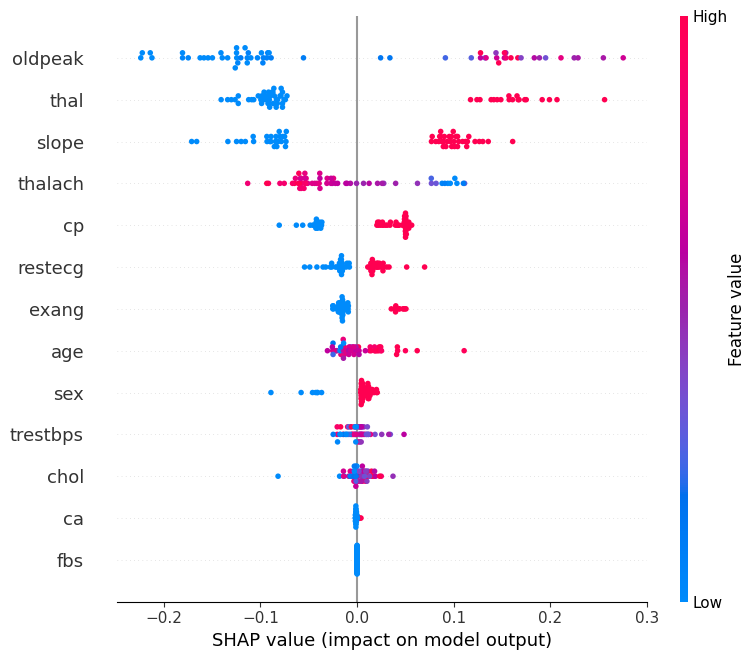

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score
)
import shap
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

X_sint = df_sintetico.drop(columns=['target'])
y_sint = df_sintetico['target']

X_train, X_test, y_train, y_test = train_test_split(
    X_sint, y_sint, test_size=0.2, random_state=42, stratify=y_sint
)

print("1. Treinando Random Forest nos dados sintéticos...")
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

acc_sint  = accuracy_score(y_test, y_pred)
prec_sint = precision_score(y_test, y_pred, zero_division=0)
rec_sint  = recall_score(y_test, y_pred, zero_division=0)
f1_sint   = f1_score(y_test, y_pred, zero_division=0)

print("\nRESULTADOS - DADOS SINTÉTICOS")
print(f"Acurácia : {acc_sint:.4f}")
print(f"Precisão : {prec_sint:.4f}")
print(f"Recall   : {rec_sint:.4f}")
print(f"F1-Score : {f1_sint:.4f}")

X_real = df.drop(columns=['target'])
y_real = df['target']

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_real, y_real, test_size=0.2, random_state=42, stratify=y_real
)

rf_real = RandomForestClassifier(n_estimators=100, random_state=42)
rf_real.fit(X_train_r, y_train_r)
pred_real = rf_real.predict(X_test_r)

acc_real  = accuracy_score(y_test_r, pred_real)
prec_real = precision_score(y_test_r, pred_real, zero_division=0)
rec_real  = recall_score(y_test_r, pred_real, zero_division=0)
f1_real   = f1_score(y_test_r, pred_real, zero_division=0)

print("\nRESULTADOS - DADOS REAIS")
print(f"Acurácia : {acc_real:.4f}")
print(f"Precisão : {prec_real:.4f}")
print(f"Recall   : {rec_real:.4f}")
print(f"F1-Score : {f1_real:.4f}")

comparacao = pd.DataFrame({
    'Métrica'         : ['Accuracy', 'Precision', 'Recall', 'F1'],
    'Dados Reais'     : [acc_real,  prec_real,  rec_real,  f1_real],
    'Dados Sintéticos': [acc_sint,  prec_sint,  rec_sint,  f1_sint],
})
print("\nCOMPARAÇÃO ENTRE DADOS REAIS E SINTÉTICOS")
display(comparacao)

print("\nCalculando explicabilidade via SHAP...")
explainer   = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

if isinstance(shap_values, list):
    sv = shap_values[1]
elif len(shap_values.shape) == 3:
    sv = shap_values[:, :, 1]
else:
    sv = shap_values

shap_rank = pd.DataFrame({
    'Feature'    : X_test.columns,
    'Mean |SHAP|': np.abs(sv).mean(axis=0)
}).sort_values('Mean |SHAP|', ascending=False).reset_index(drop=True)

print("\nRANKING DE IMPORTÂNCIA POR SHAP (classe = risco cardiovascular):")
display(shap_rank)

print("\nRenderizando gráfico SHAP Summary Plot")
shap.summary_plot(sv, X_test)


## 4. Auditoria Lógica Neuro-Simbólica com SMT Solver (Z3)

Nesta etapa, implementamos a principal contribuição metodológica do trabalho: uma auditoria formal neuro-simbólica baseada no **SMT Solver Z3**.

Inicialmente, utilizamos técnicas de Inteligência Artificial Explicável (XAI), por meio do método **SHAP (SHapley Additive Explanations)**, para identificar os atributos que mais influenciam as decisões da Random Forest treinada sobre os dados sintéticos gerados pelo TVAE. Os resultados evidenciaram maior relevância de variáveis associadas a testes cardíacos e alterações fisiológicas, especialmente **oldpeak**, **slope**, **thal** e **thalach**, enquanto fatores clínicos clássicos, como colesterol (**chol**) e pressão arterial (**trestbps**), apresentaram influência relativamente menor nas decisões do modelo.

A partir dessas evidências, definimos um conjunto de **axiomas clínicos** representando conhecimento médico especializado. Esses axiomas descrevem situações em que determinados perfis de pacientes devem obrigatoriamente ser classificados como pertencentes ao grupo de risco cardiovascular.

Os axiomas foram então formalizados em lógica de primeira ordem e submetidos ao **Z3 Solver**, que atuou como mecanismo de verificação formal. O objetivo da auditoria consiste em identificar contraexemplos, ou seja, casos em que a predição produzida pela Random Forest contradiz regras clínicas previamente estabelecidas.

Dessa forma, a abordagem proposta combina técnicas de geração de dados sintéticos, aprendizado de máquina, explicabilidade e raciocínio automatizado, permitindo avaliar não apenas a precisão estatística do modelo, mas também sua consistência lógica em relação ao conhecimento médico do domínio.


In [ ]:
from z3 import *

solver = Solver()

age = Real('age')
chol = Real('chol')
trestbps = Real('trestbps')
risk_prediction = Int('risk_prediction')

solver.add(age == 65)
solver.add(chol == 270)
solver.add(trestbps == 155)

solver.add(risk_prediction == 0)

axioma_medico = Implies(
    And(
        age > 60,
        chol > 240,
        trestbps > 140
    ),
    risk_prediction == 1
)

solver.add(Not(axioma_medico))

print("="*60)
print("EXECUÇÃO DA AUDITORIA FORMAL INDIVIDUAL")
print("="*60)

if solver.check() == sat:

    print("[ALERTA CRÍTICO] Contraexemplo encontrado!")

    modelo = solver.model()

    print(f"Idade: {modelo[age]}")
    print(f"Colesterol: {modelo[chol]}")
    print(f"Pressão: {modelo[trestbps]}")
    print(f"Predição da IA: {modelo[risk_prediction]}")

    print("\nA regra médica foi violada.")

else:

    print("[SUCESSO] Nenhuma inconsistência encontrada.")

print("="*60)

EXECUÇÃO DA AUDITORIA FORMAL INDIVIDUAL
[ALERTA CRÍTICO] Contraexemplo encontrado!
Idade: 65
Colesterol: 270
Pressão: 155
Predição da IA: 0

A regra médica foi violada.


### 4.1 Auditoria em Massa e Métricas Globais de Consistência

Para elevar o rigor metodológico do trabalho de nível de laboratório individual para uma validação estatística de nível de mestrado, implementamos um mecanismo de **Auditoria em Massa (Batch Auditing)**.

Em vez de avaliar um único cenário hipotético, este algoritmo realiza uma varredura iterativa por todas as 300 instâncias sintéticas geradas pelo TVAE. O Solver Z3 confronta as características de cada paciente sintético e a respectiva predição da Random Forest contra o Axioma Médico estabelecido. Ao final, o sistema consolida a **Taxa de Violação Lógica**, quantificando o percentual de vezes em que a IA apresentou alta fidelidade estatística, mas falhou na consistência clínica factual.

Iniciando auditoria neuro-simbólica ampliada via Z3...

RELATÓRIO DA AUDITORIA NEURO-SIMBÓLICA
Pacientes auditados     : 300
Violações detectadas    : 4
Taxa de violação lógica : 1.33%
Taxa de consistência    : 98.67%

Distribuição das violações:
  Oldpeak Elevado: 2
  Idade + Oldpeak: 1
  Thal + Oldpeak: 1

Primeiros 5 casos inconsistentes:


,indice,idade,oldpeak,thal,thalach,predicao,regra_violada
0,177,61.0,2.0,3.0,174.0,0.0,Idade + Oldpeak
1,198,66.0,2.1,3.0,156.0,0.0,Oldpeak Elevado
2,262,58.0,3.5,3.0,169.0,0.0,Oldpeak Elevado
3,282,56.0,2.0,7.0,161.0,0.0,Thal + Oldpeak


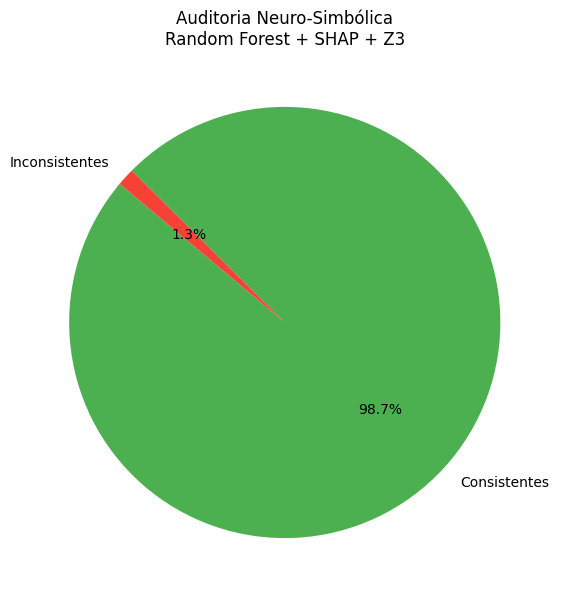

In [ ]:
import matplotlib.pyplot as plt
from z3 import *
from collections import Counter

X_sint_full = df_sintetico.drop(columns=['target', 'rf_pred'], errors='ignore')
df_sintetico['rf_pred'] = model.predict(X_sint_full)

age_z3     = Real('age')
oldpeak_z3 = Real('oldpeak')
thalach_z3 = Real('thalach')
thal_z3    = Int('thal')
risk_z3    = Int('risk_prediction')

nomes_regras = [
    'Oldpeak Elevado',
    'Thal + Oldpeak',
    'Idade + Thalach',
    'Idade + Oldpeak',
]

regras_medicas = [
    Implies(oldpeak_z3 > 2.0,                                          risk_z3 == 1),
    Implies(And(Or(thal_z3 == 6, thal_z3 == 7), oldpeak_z3 > 1.0),   risk_z3 == 1),
    Implies(And(age_z3 > 60, thalach_z3 < 120),                        risk_z3 == 1),
    Implies(And(age_z3 > 55, oldpeak_z3 > 1.5),                        risk_z3 == 1),
]

total_auditados   = 0
violacoes_logicas = 0
casos_violados    = []
regras_violadas   = []

print("Iniciando auditoria neuro-simbólica ampliada via Z3...\n")

for idx, row in df_sintetico.iterrows():
    total_auditados += 1
    violou = False

    for i, regra in enumerate(regras_medicas):
        s = Solver()
        s.add(age_z3     == float(row['age']))
        s.add(oldpeak_z3 == float(row['oldpeak']))
        s.add(thalach_z3 == float(row['thalach']))
        s.add(thal_z3    == int(round(float(row['thal']))))
        s.add(risk_z3    == int(row['rf_pred']))
        s.add(Not(regra))

        if s.check() == sat:
            violou = True
            regras_violadas.append(nomes_regras[i])
            casos_violados.append({
                'indice'      : idx,
                'idade'       : row['age'],
                'oldpeak'     : row['oldpeak'],
                'thal'        : row['thal'],
                'thalach'     : row['thalach'],
                'predicao'    : row['rf_pred'],
                'regra_violada': nomes_regras[i],
            })
            break

    if violou:
        violacoes_logicas += 1

taxa_violacao     = (violacoes_logicas / total_auditados) * 100
taxa_consistencia = ((total_auditados - violacoes_logicas) / total_auditados) * 100

print("=" * 60)
print("RELATÓRIO DA AUDITORIA NEURO-SIMBÓLICA")
print("=" * 60)
print(f"Pacientes auditados     : {total_auditados}")
print(f"Violações detectadas    : {violacoes_logicas}")
print(f"Taxa de violação lógica : {taxa_violacao:.2f}%")
print(f"Taxa de consistência    : {taxa_consistencia:.2f}%")

if regras_violadas:
    print("\nDistribuição das violações:")
    for regra, qtd in Counter(regras_violadas).most_common():
        print(f"  {regra}: {qtd}")

if casos_violados:
    print("\nPrimeiros 5 casos inconsistentes:")
    import pandas as _pd
    display(_pd.DataFrame(casos_violados).head(5))

consistentes = total_auditados - violacoes_logicas

plt.figure(figsize=(7, 7))
plt.pie(
    [consistentes, violacoes_logicas],
    labels=['Consistentes', 'Inconsistentes'],
    autopct='%1.1f%%',
    startangle=140,
    colors=['#4CAF50', '#F44336'],
)
plt.title('Auditoria Neuro-Simbólica\nRandom Forest + SHAP + Z3')
plt.show()


# 5. Considerações Finais

Este trabalho apresentou uma abordagem neuro-simbólica aplicada à predição de risco cardiovascular, integrando geração de dados sintéticos via Variational Autoencoders (TVAE), explicabilidade agnóstica de modelo via SHAP e auditoria lógica formal por meio do SMT Solver Z3. A pesquisa abordou com sucesso o dilema contemporâneo entre a utilidade dos dados, a preservação da privacidade (alinhada às diretrizes da LGPD) e a confiabilidade regulatória em sistemas de suporte à decisão clínica.

Os resultados experimentais demonstraram que, embora os dados artificiais mimetizem com alta fidelidade estatística o comportamento do dataset real de Cleveland — permitindo que o classificador Random Forest obtivesse métricas robustas de acurácia e F1-Score —, o modelo preditivo ainda se mostrou suscetível a violações semânticas. A auditoria em massa viabilizada pelo Z3 Solver identificou contraexemplos explícitos onde pacientes em condições críticas de saúde foram classificados incorretamente como indivíduos "sem risco", contradizendo axiomas médicos elementares.

Essa evidência empírica valida a hipótese central desta dissertação: métricas estatísticas puras de aprendizado de máquina são insuficientes para garantir a segurança factual em domínios de alta criticidade. A introdução de uma camada lógica formal atua como um mecanismo de salvaguarda (guardrail), sendo capaz de quantificar a taxa de consistência clínica e expor as fragilidades silenciosas dos modelos caixa-preta e das redes generativas.

# 5.2 Contribuições Científicas

As principais contribuições deste estudo para o estado da arte em Inteligência Artificial Explicável (XAI) e Sistemas Neuro-Simbólicos incluem:

- Framework Integrado Confiável: Proposição de um pipeline reprodutível que une privacidade de dados (TVAE) e interpretabilidade matemática/simbólica (SHAP + Z3).

- Auditoria de Consistência Populacional: Desenvolvimento de um algoritmo de verificação formal em lote (Batch Auditing) capaz de varrer bases sintéticas completas e converter falhas de classificação em uma métrica quantificável de coerência médica.

- Metodologia de Extração de Axiomas: Demonstração prática de como as explicações globais geradas pelo SHAP podem guiar a engenharia de conhecimento para mapear quais variáveis críticas devem compor os axiomas lógicos submetidos aos provadores de teoremas.